In [9]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.cluster import DBSCAN
from typing import Callable
import networkx as nx
from sklearn.neighbors import NearestNeighbors


In [10]:
def lens(X):
    """
    Lens (filter) function used in the Mapper algorithm.

    This function maps high-dimensional data to a 1D representation.
    Here, we simply extract the first column of the DataFrame and
    convert it into a NumPy array.

    it will returns:
    numpy.ndarray
        1D array of lens values.
    """
    return X.iloc[:, 0].to_numpy()


def make_interval_cover(lens_values, n_intervals=12, overlap=0.3):
    """
    Create an overlapping interval cover of the lens values.

    The cover divides the range of the lens into several intervals
    with a specified overlap. These intervals define subsets of data
    that will be clustered independently in Mapper.

    Parameters:
    lens_values : numpy.ndarray
        Output of the lens function.
    n_intervals : int
        Number of intervals in the cover.
    overlap : float
        Fraction of overlap between consecutive intervals (0 to 1).

    
    we will get list of tuples
        Each tuple (a, b) represents an interval [a, b].
    """
    # Find minimum and maximum of the lens values
    min_val = lens_values.min()
    max_val = lens_values.max()

   
    padding = 0.1 * (max_val - min_val)   # Add padding so boundary points are not excluded
    min_val -= padding
    max_val += padding
   
    step = (max_val - min_val) / n_intervals   # Width of each interval without overlap

    # Amount by which intervals overlap
    overlap_amount = step * overlap

    cover_set = []

   
    for i in range(n_intervals):
        a = min_val + i * step - (overlap_amount if i > 0 else 0)  # Left endpoint (extend left if not the first interval)

        
        b = min_val + (i + 1) * step + (overlap_amount if i < n_intervals - 1 else 0) # Right endpoint (extend right if not the last interval)

        cover_set.append((a, b))

    return cover_set


def plot_mapper_graph(vertex_set, edge_set, title="Mapper Graph"):
    """
    Visualize the Mapper graph.

    Each vertex represents a cluster of data points.
    An edge is drawn between two vertices if they share
    at least one data point.
    """
    
    G = nx.Graph() # Initialize an undirected graph

    # Add one node for each vertex (cluster)
    for i in range(len(vertex_set)):
        G.add_node(i)

    vertex_lookup = {frozenset(v): i for i, v in enumerate(vertex_set)}

    # Add edges between nodes that share data points
    for v1, v2 in edge_set:
        i = vertex_lookup[frozenset(v1)]
        j = vertex_lookup[frozenset(v2)]
        G.add_edge(i, j)

    
    node_sizes = [max(100, len(v) * 1) for v in vertex_set] # Node size proportional to cluster size

    if len(G.nodes) == 0:    # Let's handle empty graph
        print("Empty Mapper graph.")
        return

    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G, seed=42)

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=node_sizes,
        font_size=10
    )

    plt.title(title)
    plt.show()


def mapper(data: pd.DataFrame, lens: Callable, cover_set: list, clustering_alg: DBSCAN):
    """
    Core Mapper algorithm implementation.

    Steps:
    1. Apply the lens function to the data.
    2. Slice the data using the interval cover.
    3. Cluster each slice independently.
    4. Create vertices from clusters.
    5. Connect vertices that share data points.

    Returns:
    vertex_set : list of sets
        Each set represents a Mapper node (cluster).
    edge_set : list of tuples
        Each tuple represents an edge between two nodes.
    """
    vertex_set = []  # Stores clusters (nodes)
    edge_set = []    # Stores connections (edges)


    lens_values = lens(data)

    # Process each interval in the cover
    for i, Ui in enumerate(cover_set):
        ax, bx = Ui

        # Select data points whose lens values fall in the interval
        Xi = data[(lens_values >= ax) & (lens_values <= bx)]

        labels = clustering_alg.fit(Xi).labels_    # Apply clustering algorithm
        
        unique_labels = set(labels)
        if -1 in unique_labels:       # get unique cluster labels (ignore noise labeled as -1)
            unique_labels.remove(-1)

        
        for j, cluster_label in enumerate(sorted(unique_labels)):   # let's create a vertex for each cluster
            members = Xi.index[labels == cluster_label]    
            vertex = set(members)
            vertex_set.append(vertex)

    
    for i, vertex1 in enumerate(vertex_set):   # Create edges between vertices that share data points
        for j, vertex2 in enumerate(vertex_set):
            if i < j:
                if vertex1.intersection(vertex2):
                    edge_set.append((vertex1, vertex2))

    return vertex_set, edge_set


In [11]:
df = pd.read_csv('noisy_annuli_bridge.csv')

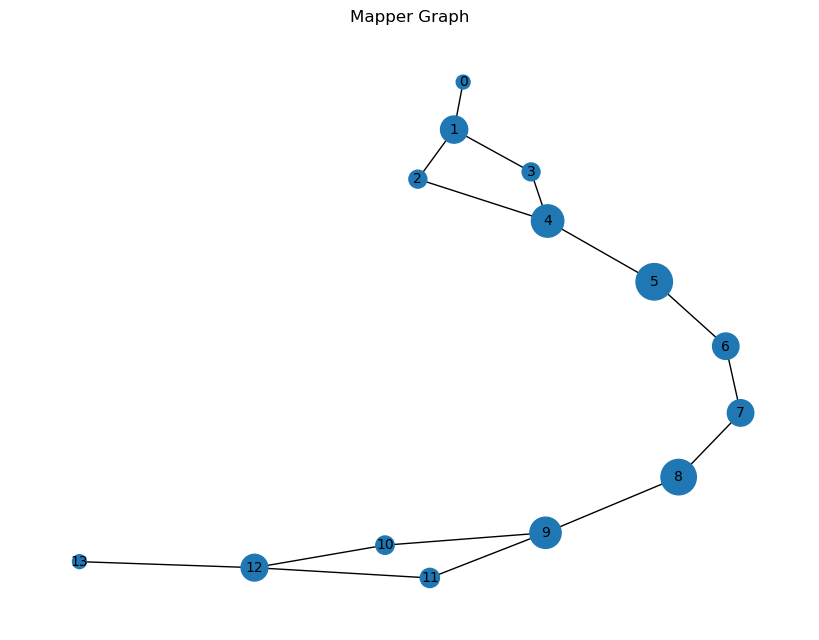

In [12]:
clustering_alg = DBSCAN(eps=0.6, min_samples=5)
data = df[['x', 'y']]



cover_set = make_interval_cover(lens(data), n_intervals=12, overlap=0.3)
vertex_set, edge_set = mapper(data, lens, cover_set, clustering_alg)
plot_mapper_graph(vertex_set, edge_set)

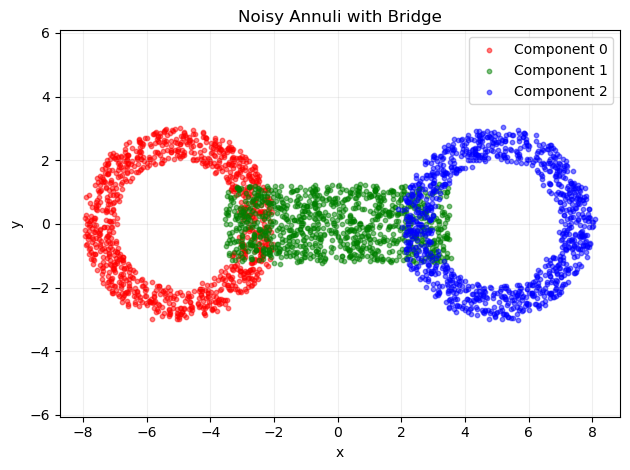

In [13]:
colors = ['red', 'green', 'blue']
for label, color in enumerate(colors):
    mask = df['label'] == label
    plt.scatter(df.loc[mask, 'x'], df.loc[mask, 'y'],
               color=color, alpha=0.5, s=10, label=f'Component {label}')

plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Noisy Annuli with Bridge')
plt.legend()
plt.grid(True, alpha=0.2)
plt.axis('equal')
plt.tight_layout()
plt.show()

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def dbscan_elbow(X, min_samples=5):
    """
    Plot k-distance graph for DBSCAN epsilon selection.

    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
    min_samples : int
        DBSCAN min_samples (k in k-distance plot)
    """
    neigh = NearestNeighbors(n_neighbors=min_samples)
    neigh.fit(X)

    distances, _ = neigh.kneighbors(X)
    k_distances = distances[:, -1]  # distance to k-th nearest neighbor
    k_distances = np.sort(k_distances)

    plt.figure(figsize=(6, 4))
    plt.plot(k_distances)
    plt.xlabel("Points sorted by distance")
    plt.ylabel(f"{min_samples}-NN distance")
    plt.title("DBSCAN ε Elbow (k-distance plot)")
    plt.grid(True)
    plt.show()

    return k_distances
